In [1]:
import torch
from base_model import *
from utils import *
from custom_layer import *

In [2]:
torch.backends.mkldnn.enabled = True

In [3]:
train_dataset, val_dataset = get_dataset()
criterion = torch.nn.CrossEntropyLoss()

In [4]:
block0 = nn.Sequential(
    nn.BatchNorm2d(3),#Not normal to use batchnorm at the beginning of the network, but based on empirical results, it can improve the performance of small model
    nn.Conv2d(3, 30, 3, padding=1, groups=3),
    nn.BatchNorm2d(30),
    nn.PReLU(),

    nn.Conv2d(30, 30, 1),   # pointwise conv
    nn.BatchNorm2d(30),
    nn.PReLU(),

    nn.Conv2d(30, 30, 3, padding=1, groups=30),
    nn.BatchNorm2d(30),
    nn.PReLU(),
    HybridPoolingV0(30),          # 32 → 16

    nn.Conv2d(30, 30, 1),   # pointwise conv
    nn.BatchNorm2d(30),
    nn.PReLU(),
)
block1 = nn.Sequential(
    # -------- Block 2 --------
    nn.Conv2d(30, 60, 3, padding=1,groups=30),
    nn.BatchNorm2d(60),
    nn.PReLU(),

    nn.Conv2d(60, 60, 1),   # pointwise conv
    nn.BatchNorm2d(60),
    nn.PReLU(),

    nn.Conv2d(60, 60, 3, padding=1,groups=60),
    nn.BatchNorm2d(60),
    nn.PReLU(),
    HybridPoolingV0(60),          # 16 → 8

    nn.Conv2d(60, 60, 1),   # pointwise conv
    nn.BatchNorm2d(60),
    nn.PReLU(),
)
block2 = nn.Sequential(
    # -------- Block 3 --------
    nn.Conv2d(60, 80, 3, padding=1, groups=20),
    nn.BatchNorm2d(80),
    nn.PReLU(),

    nn.Conv2d(80, 80, 1),   # pointwise conv
    nn.BatchNorm2d(80),
    nn.PReLU(),

    nn.Conv2d(80, 60, 3, padding=1, groups=20),
    nn.BatchNorm2d(60),
    nn.PReLU(),
    HybridPoolingV0(60),          # 8 → 4

    nn.Conv2d(60, 60, 1),   # pointwise conv
    nn.BatchNorm2d(60),
    nn.PReLU(),
)
block3 = nn.Sequential(
    # -------- Block 4 --------
    nn.Conv2d(60, 60, 3, padding=1, groups=60),
    nn.BatchNorm2d(60),
    nn.PReLU(),

    # nn.Conv2d(60, 60, 1),   # pointwise conv
    # nn.BatchNorm2d(60),
    # nn.PReLU(),

    nn.Conv2d(60, 60, 3, padding=1, groups=60),
    nn.BatchNorm2d(60),
    nn.PReLU(),
    HybridPoolingV0(60),          # 4 → 2

    # nn.Conv2d(60, 60, 1),   # pointwise conv
    # nn.BatchNorm2d(60),
    # nn.PReLU(),
)

classifier = nn.Sequential(
    nn.Flatten(),
    nn.Linear(240, 10)
)

In [5]:
model38_0 = BaseModelF32([block0, block1, block2, block3], classifier)
he_initialization(model38_0)
describe(model38_0)

MACs: 4.97 MMac, Params: 31.15 k
Layer (type:depth-idx)                        Output Shape              Param #
BaseModelF32                                  [1, 10]                   --
├─ModuleList: 1-1                             --                        --
│    └─Sequential: 2-1                        [1, 30, 16, 16]           --
│    │    └─BatchNorm2d: 3-1                  [1, 3, 32, 32]            6
│    │    └─Conv2d: 3-2                       [1, 30, 32, 32]           300
│    │    └─BatchNorm2d: 3-3                  [1, 30, 32, 32]           60
│    │    └─PReLU: 3-4                        [1, 30, 32, 32]           1
│    │    └─Conv2d: 3-5                       [1, 30, 32, 32]           930
│    │    └─BatchNorm2d: 3-6                  [1, 30, 32, 32]           60
│    │    └─PReLU: 3-7                        [1, 30, 32, 32]           1
│    │    └─Conv2d: 3-8                       [1, 30, 32, 32]           300
│    │    └─BatchNorm2d: 3-9                  [1, 30, 32, 32] 

Loading checkpoint from model_weights/model38_0.pt
Starting
Epoch 1/60: Train loss = 1.1495, Train accuracy = 0.5982, Test loss = 1.1039, Test accuracy = 0.6231
Epoch 2/60: Train loss = 0.8228, Train accuracy = 0.7120, Test loss = 0.8084, Test accuracy = 0.7218
Epoch 3/60: Train loss = 0.7699, Train accuracy = 0.7298, Test loss = 0.8158, Test accuracy = 0.7238
Epoch 4/60: Train loss = 0.6450, Train accuracy = 0.7753, Test loss = 0.6751, Test accuracy = 0.7694
Epoch 5/60: Train loss = 0.6178, Train accuracy = 0.7826, Test loss = 0.6693, Test accuracy = 0.7728
Epoch 6/60: Train loss = 0.6564, Train accuracy = 0.7758, Test loss = 0.7014, Test accuracy = 0.7751
Epoch 7/60: Train loss = 0.5704, Train accuracy = 0.8012, Test loss = 0.6210, Test accuracy = 0.7873
Epoch 8/60: Train loss = 0.5360, Train accuracy = 0.8151, Test loss = 0.5735, Test accuracy = 0.8073
Epoch 9/60: Train loss = 0.5270, Train accuracy = 0.8171, Test loss = 0.5779, Test accuracy = 0.8078
Epoch 10/60: Train loss = 0.487

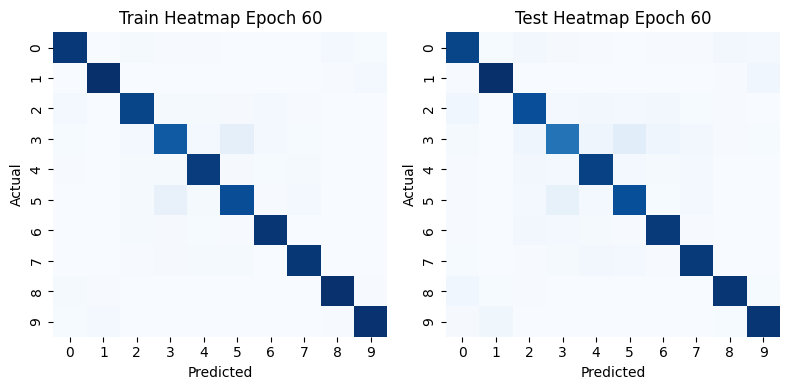

<Figure size 1200x600 with 0 Axes>

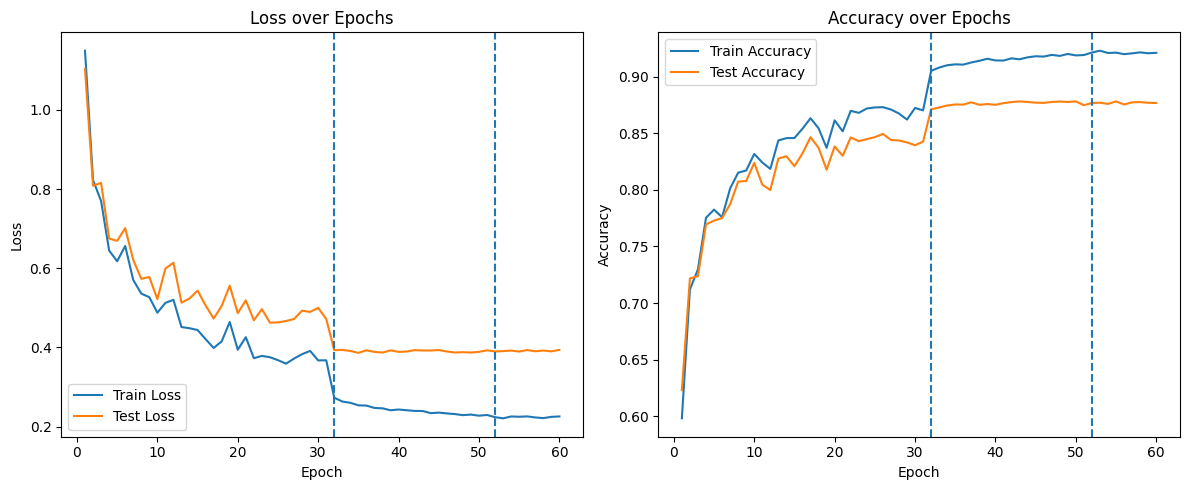

In [6]:
trainf32(model38_0,"model_weights/model38_0.pt",criterion,train_dataset,val_dataset, batch_size=128)

In [7]:
model38_1 = BaseModelF32([block0, block1, block2, block3], classifier)
he_initialization(model38_1)
describe(model38_1)

MACs: 4.97 MMac, Params: 31.15 k
Layer (type:depth-idx)                        Output Shape              Param #
BaseModelF32                                  [1, 10]                   --
├─ModuleList: 1-1                             --                        --
│    └─Sequential: 2-1                        [1, 30, 16, 16]           --
│    │    └─BatchNorm2d: 3-1                  [1, 3, 32, 32]            6
│    │    └─Conv2d: 3-2                       [1, 30, 32, 32]           300
│    │    └─BatchNorm2d: 3-3                  [1, 30, 32, 32]           60
│    │    └─PReLU: 3-4                        [1, 30, 32, 32]           1
│    │    └─Conv2d: 3-5                       [1, 30, 32, 32]           930
│    │    └─BatchNorm2d: 3-6                  [1, 30, 32, 32]           60
│    │    └─PReLU: 3-7                        [1, 30, 32, 32]           1
│    │    └─Conv2d: 3-8                       [1, 30, 32, 32]           300
│    │    └─BatchNorm2d: 3-9                  [1, 30, 32, 32] 

Loading checkpoint from model_weights/model38_1.pt
Starting
Epoch 1/60: Train loss = 0.9610, Train accuracy = 0.6636, Test loss = 0.9278, Test accuracy = 0.6807
Epoch 2/60: Train loss = 0.7638, Train accuracy = 0.7326, Test loss = 0.7817, Test accuracy = 0.7368
Epoch 3/60: Train loss = 0.6614, Train accuracy = 0.7698, Test loss = 0.6593, Test accuracy = 0.7763
Epoch 4/60: Train loss = 0.6653, Train accuracy = 0.7718, Test loss = 0.6924, Test accuracy = 0.7703
Epoch 5/60: Train loss = 0.5909, Train accuracy = 0.7957, Test loss = 0.6068, Test accuracy = 0.7914
Epoch 6/60: Train loss = 0.5866, Train accuracy = 0.7938, Test loss = 0.6241, Test accuracy = 0.7848
Epoch 7/60: Train loss = 0.4914, Train accuracy = 0.8293, Test loss = 0.5266, Test accuracy = 0.8189
Epoch 8/60: Train loss = 0.4961, Train accuracy = 0.8297, Test loss = 0.5336, Test accuracy = 0.8238
Epoch 9/60: Train loss = 0.4901, Train accuracy = 0.8308, Test loss = 0.5337, Test accuracy = 0.8221
Epoch 10/60: Train loss = 0.493

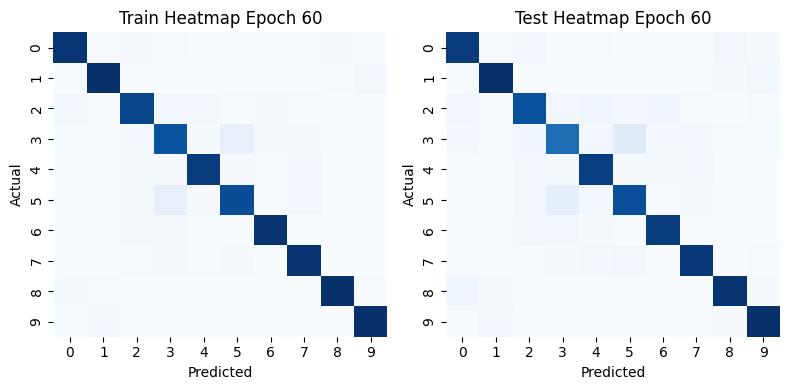

<Figure size 1200x600 with 0 Axes>

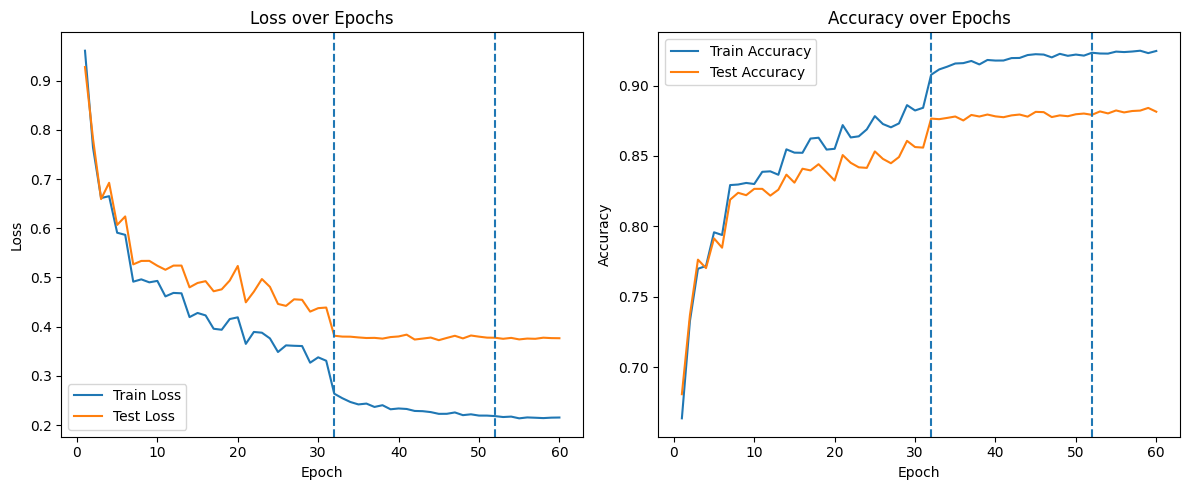

In [8]:
trainf32(model38_1,"model_weights/model38_1.pt",criterion,train_dataset,val_dataset, batch_size=64)